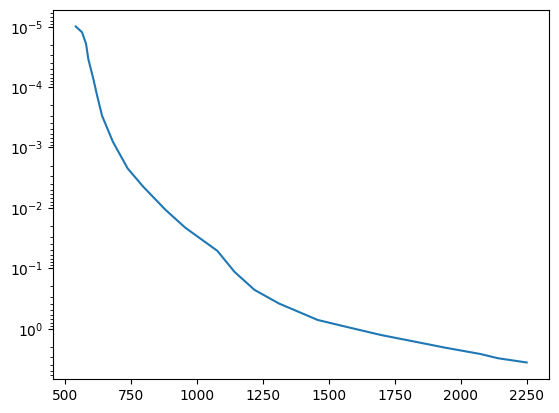

In [25]:
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt('pt.csv', delimiter=',',skip_header=1)
t=data[:,0]#[::-1]
p=10**(-data[:,1]+1)

plt.plot(t,p)
plt.gca().invert_yaxis()
plt.yscale('log')

pt=np.full(shape=(len(t),2),fill_value=np.nan)
pt[:,0]=p
pt[:,1]=t
np.savetxt(f'Sing+2024_PT.txt',pt,delimiter=' ',header='pressure[bar] temperature[K]')

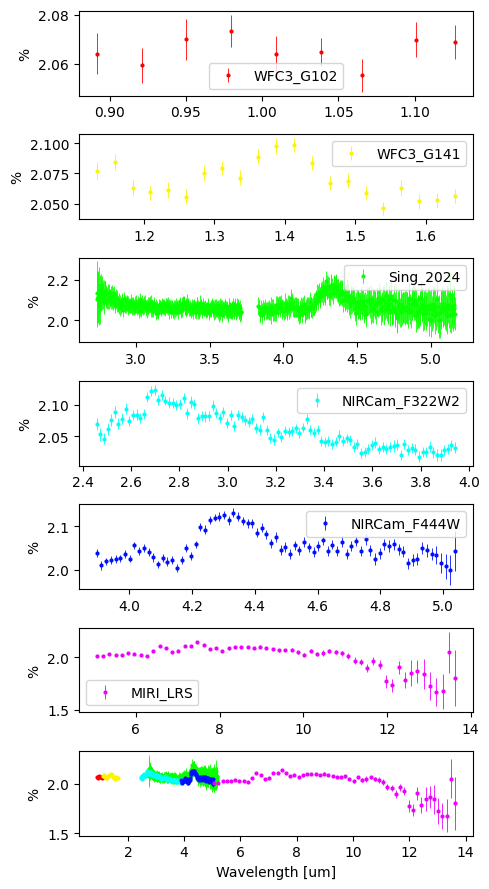

In [2]:
import numpy as np
import pathlib
import os
import re
import pandas as pd
import matplotlib.pyplot as plt


def load_spectrum(project_path,input_file):

    def _clean_col(name):
        """Normalize column names for matching"""
        name = name.lower()
        name = re.sub(r'\(.*?\)', '', name)  # remove units in brackets
        return name.strip()


    def _find_column(columns, keywords, exclude_keywords=None):
        exclude_keywords = exclude_keywords or []

        # First pass: exact/strong matches
        for col in columns:
            clean = _clean_col(col)

            if any(k == clean for k in keywords):
                if not any(ex in clean for ex in exclude_keywords):
                    return col

        # Second pass: substring matches
        for col in columns:
            clean = _clean_col(col)

            if any(k in clean for k in keywords):
                if not any(ex in clean for ex in exclude_keywords):
                    return col

        return None
    
    # check if transit depth, or if it should still be squared
    def _needs_square(colname):
        clean = _clean_col(colname)

        # indicators that it's already squared
        squared_indicators = ["2", "^2", "**2", "squared", "sq"]

        # indicators that it's a ratio
        ratio_indicators = ["rp/rs", "rprs", "rp_rs", "rplanet/rstar"]

        has_ratio = any(r in clean for r in ratio_indicators)
        has_square = any(s in clean for s in squared_indicators)

        return has_ratio and not has_square

    # 1. Resolve file path
    file = pathlib.Path(f'{project_path}/{input_file}')

    if not file.exists():
        raise FileNotFoundError(file)

    # 2. Detect format
    suffix = file.suffix.lower()

    if suffix == ".csv":
        df = pd.read_csv(file)
    else:
        # try reading header
        with open(file, 'r') as f:
            first_line = f.readline()

        if first_line.startswith("#"):
            header = first_line[1:].strip().split()
            data = np.genfromtxt(file, skip_header=1)
            df = pd.DataFrame(data, columns=header)
        else:
            # no header → fallback
            data = np.genfromtxt(file)
            df = pd.DataFrame(data)

    # 3. Identify columns
    cols = df.columns
    wl_col  = _find_column(cols, ["wave", "wl", "lambda"])
    fl_col = _find_column(cols, ["flux", "depth", "rp", "rplanet"],
                            exclude_keywords=["err", "unc", "sigma"])
    err_col = _find_column(cols, ["err","unc","sigma"])

    # 4. Fallback if no names
    if wl_col is None or fl_col is None:
        # assume standard ordering
        wl_col  = cols[0]
        fl_col  = cols[1]
        err_col = cols[2] if len(cols) > 2 else None

    # 5. Assign arrays
    wl  = df[wl_col].to_numpy()
    fl  = df[fl_col].to_numpy()
    err = df[err_col].to_numpy() if err_col else np.full_like(fl, np.nan)

    # convert Rp/Rs → depth if needed
    if _needs_square(fl_col):
        #print(f"[INFO] Column '{fl_col}' detected as Rp/Rs → squaring to get transit depth.")
        fl = fl**2

    fl*=100 # so that it is in % (nicer)
    err*=100

    return wl,fl,err


spectra = ['WFC3_G102_Fiducial_Pegasus_Spectrum.txt',
           'WFC3_G141_Fiducial_Pegasus_Spectrum.txt',
           'Sing_2024_Fig2_WASP107b_transit_spec_data.csv',
           'NIRCam_F322W2_Fiducial_Eureka_Spectrum.txt',
           'NIRCam_F444W_Fiducial_Eureka_Spectrum.txt',   
           'MIRI_LRS_Fiducial_Eureka_Spectrum.txt']
project_path = './spectra/'

def nice_colors(n):
    cmap = plt.cm.hsv
    return [cmap(i / n) for i in range(n)]

fig,ax=plt.subplots(len(spectra)+1,1,figsize=(5,9),dpi=100)
colors = nice_colors(len(spectra))
for i,spec in enumerate(spectra):
    wl,fl,err = load_spectrum(project_path,spec)
    label = '_'.join(spec.split('_')[:2])
    ax[i].errorbar(wl,fl,yerr=err,fmt='o',markersize=2,elinewidth=0.6,label=label,color=colors[i])
    ax[i].legend()
    ax[i].set_ylabel('%')
    ax[-1].errorbar(wl,fl,yerr=err,fmt='o',markersize=2,elinewidth=0.6,label=label,color=colors[i])

ax[-1].set_ylabel('%')
ax[-1].set_xlabel('Wavelength [um]')
fig.tight_layout()


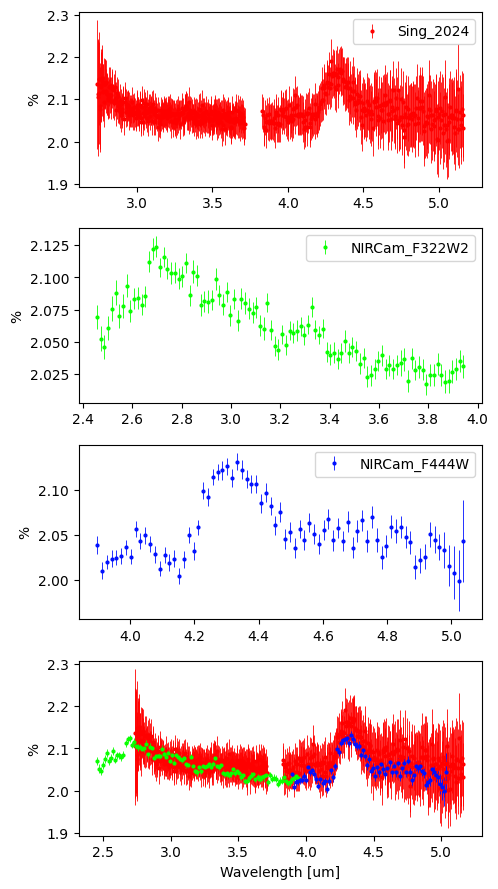

In [ ]:
spectra = ['Sing_2024_Fig2_WASP107b_transit_spec_data.csv',
           'NIRCam_F322W2_Fiducial_Eureka_Spectrum.txt',
           'NIRCam_F444W_Fiducial_Eureka_Spectrum.txt']

fig,ax=plt.subplots(len(spectra)+1,1,figsize=(5,9),dpi=100)
colors = nice_colors(len(spectra))
for i,spec in enumerate(spectra):
    wl,fl,err = load_spectrum(project_path,spec)
    label = '_'.join(spec.split('_')[:2])
    ax[i].errorbar(wl,fl,yerr=err,fmt='o',markersize=2,elinewidth=0.6,label=label,color=colors[i])
    ax[i].legend()
    ax[i].set_ylabel('%')
    ax[-1].errorbar(wl,fl,yerr=err,fmt='o',markersize=2,elinewidth=0.6,label=label,color=colors[i])

ax[-1].set_ylabel('%')
ax[-1].set_xlabel('Wavelength [um]')
fig.tight_layout()